# Feature Extraction - Daphnet FoG Dataset

**Objective:** Extract multi-domain features from windowed sensor data for FoG detection.

**Features extracted:**
- Time-domain: mean, std, skewness, kurtosis, RMS, median, IQR, cadence
- Frequency-domain: PSD peak, total energy, band powers, freezing index
- Wavelet: energy per level, entropy
- Nonlinear: sample entropy, fractal dimension

**Pipeline:**
1. Load windowed LOSO splits
2. Initialize signal cleaner and feature extractor
3. Process all folds: clean signals → extract features → save CSVs
4. Analyze extracted features with visualizations

In [27]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from tqdm import tqdm

from features import FeatureExtractor
from processing import SignalCleaner

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## 1. Load Windowed Data

In [28]:
# Load binary LOSO splits
data_path = Path('../../outputs/datasets_csv/daphnet_loso_windows_binary.pkl')

with open(data_path, 'rb') as f:
    loso_splits = pickle.load(f)

print(f"✅ Loaded {len(loso_splits)} LOSO folds")
print(f"   Total train windows: {sum([len(fold['y_train']) for fold in loso_splits]):,}")
print(f"   Total test windows: {sum([len(fold['y_test']) for fold in loso_splits]):,}")

✅ Loaded 10 LOSO folds
   Total train windows: 80,055
   Total test windows: 4,451


## 2. Initialize Cleaner and Extractor

In [29]:
# Signal cleaner (MAD-based outlier detection)
cleaner = SignalCleaner(
    outlier_thresh_mul=3.0,
    outlier_poly_order=3
)

print("✅ Signal cleaner initialized")
print(f"   MAD threshold: {cleaner.outlier_thresh_mul}")
print(f"   Polynomial order: {cleaner.outlier_poly_order}")

✅ Signal cleaner initialized
   MAD threshold: 3.0
   Polynomial order: 3


In [ ]:
# Feature extractor
SAMPLING_RATE = 64  # Hz for Daphnet

extractor = FeatureExtractor(
    sampling_rate=SAMPLING_RATE,
    extract_time=True,
    extract_frequency=True,
    extract_wavelet=True,
    extract_nonlinear=True  # Enabled for robust cross-dataset pipeline
)

# Channel groups for per-sensor magnitude computation
# Daphnet: 9 channels — all accelerometer (no gyroscope)
# acc_forward/vertical/lateral per body position
CHANNEL_GROUPS = {
    'acc_ankle': [0, 1, 2],
    'acc_thigh':  [3, 4, 5],
    'acc_trunk':  [6, 7, 8],
}

print("✅ Feature extractor initialized")
print(f"   Sampling rate: {SAMPLING_RATE} Hz")
print(f"   Time-domain: ✅")
print(f"   Frequency-domain: ✅")
print(f"   Wavelet: ✅")
print(f"   Nonlinear: ✅")
print(f"   Channel groups: {list(CHANNEL_GROUPS.keys())}")

✅ Feature extractor initialized
   Sampling rate: 64 Hz
   Time-domain: ✅
   Frequency-domain: ✅
   Wavelet: ✅
   Nonlinear: ❌ (disabled)
   Channel groups: ['acc_ankle', 'acc_thigh', 'acc_trunk']


## 3. Process All LOSO Folds

Extract features from all folds and save to CSV files.

In [31]:
# Output directory
feature_output_dir = Path('../../outputs/daphnet_features')
feature_output_dir.mkdir(parents=True, exist_ok=True)

print("🚀 Processing all LOSO folds...")
print("=" * 70)

for fold in tqdm(loso_splits, desc="Processing folds"):
    test_subject = fold['test_subject']

    # 1. Clean signals (remove outliers)
    X_train_clean = cleaner.clean_windows(fold['X_train'])
    X_test_clean  = cleaner.clean_windows(fold['X_test'])

    # 2. Extract features (parallel processing with all CPU cores)
    X_train_features = extractor.extract_from_windows(
        X_train_clean, n_jobs=-1, verbose=True, channel_groups=CHANNEL_GROUPS)
    X_test_features = extractor.extract_from_windows(
        X_test_clean, n_jobs=-1, verbose=True, channel_groups=CHANNEL_GROUPS)

    # 3. Save to CSV
    fold_dir = feature_output_dir / f'fold_subj_{test_subject}'
    fold_dir.mkdir(parents=True, exist_ok=True)

    X_train_features.to_csv(fold_dir / 'X_train_features.csv', index=False)
    pd.Series(fold['y_train'], name='label').to_csv(fold_dir / 'y_train.csv', index=False)
    pd.Series(fold['subjects_train'], name='subject').to_csv(fold_dir / 'subjects_train.csv', index=False)
    X_test_features.to_csv(fold_dir / 'X_test_features.csv', index=False)
    pd.Series(fold['y_test'], name='label').to_csv(fold_dir / 'y_test.csv', index=False)

print("\n" + "=" * 70)
print(f"✅ Feature extraction complete for {len(loso_splits)} folds")
print(f"📁 Output directory: {feature_output_dir}")
print("=" * 70)

🚀 Processing all LOSO folds...


Processing folds:   0%|          | 0/10 [00:00<?, ?it/s]

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:   10.2s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done  40 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done  53 tasks      | elapsed:   10.4s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.18395611920520732s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  66 tasks      | elapsed:   10.4s
[Parallel(n_jobs=-1)]: Done  81 tasks      | elapsed:   10.4s
[Parallel(n_jobs=-1)]: Done  96 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.09055900573730469s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done 130 tasks      | elapsed:   10.5s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.15429902076721191s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:   10.7s
[Parallel(n_job

🚀 Extracting features in parallel (-1 jobs)...


...

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.024352073669433594s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.09333467483520508s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.17381954193115234s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 164 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 360 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 496 tasks      | elapsed:    1.1s
[Parallel(n_jo

🚀 Extracting features in parallel (-1 jobs)...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Batch computation too fast (0.02611088752746582s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.08816385269165039s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  48 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done  74 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.18416857719421387s.) Setting batch_size=8.
[Parallel(n_jobs=-1)]: Done 104 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 164 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.5s
[Parallel(n_jobs=-1)]: Done 360 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 433 tasks      | elapsed:    1.0s
[Parallel(n_job


✅ Feature extraction complete for 10 folds
📁 Output directory: ..\..\outputs\daphnet_features


## 4. Load Sample Features for Analysis

Load features from the first fold for visualization and analysis.

In [32]:
# Load first fold for analysis (dynamically find first available fold)
available_folds = sorted([d for d in feature_output_dir.iterdir() if d.is_dir()])
if not available_folds:
    raise FileNotFoundError(f"No fold directories found in {feature_output_dir}")
sample_fold_dir = available_folds[0]

X_train_features = pd.read_csv(sample_fold_dir / 'X_train_features.csv')
y_train = pd.read_csv(sample_fold_dir / 'y_train.csv').squeeze()
X_test_features = pd.read_csv(sample_fold_dir / 'X_test_features.csv')
y_test = pd.read_csv(sample_fold_dir / 'y_test.csv').squeeze()

print(f"📊 Loaded features from: {sample_fold_dir.name}")
print(f"   Train: {X_train_features.shape}")
print(f"   Test: {X_test_features.shape}")
print(f"   Features: {X_train_features.shape[1]}")
print(f"\n📋 First 10 features:")
for i, col in enumerate(X_train_features.columns[:10], 1):
    print(f"   {i}. {col}")

📊 Loaded features from: fold_subj_S01
   Train: (7947, 301)
   Test: (474, 301)
   Features: 301

📋 First 10 features:
   1. ch0_mean
   2. ch0_std
   3. ch0_skew
   4. ch0_kurt
   5. ch0_median
   6. ch0_iqr
   7. ch0_rms
   8. ch0_peak_to_peak
   9. ch0_zero_crossing_rate
   10. ch0_psd_peak_freq


## 5. Feature Statistics

In [33]:
# Statistical summary
print("📈 Feature Statistics (Train Set):")
print(X_train_features.describe())

📈 Feature Statistics (Train Set):


c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


          ch0_mean      ch0_std     ch0_skew     ch0_kurt   ch0_median  \
count  7947.000000  7947.000000  7899.000000  7899.000000  7947.000000   
mean    -77.508922    92.230030     0.029526     0.850649   -79.405618   
std     257.218521    97.544208     0.355623     2.764789   258.258801   
min    -808.670554     0.000000    -3.482808    -1.952741  -808.000000   
25%    -240.284918     9.909834    -0.153586     0.023662  -246.675486   
50%     -40.504085    64.149437     0.008005     0.716440   -40.000000   
75%     109.850598   148.555345     0.206824     1.473327   111.000000   
max     714.765228  2606.790717    14.875288   229.473606   686.000000   

           ch0_iqr      ch0_rms  ch0_peak_to_peak  ch0_zero_crossing_rate  \
count  7947.000000  7947.000000       7947.000000             7947.000000   
mean     83.324609   252.704320        544.538732                0.074130   
std      83.410573   162.248475        559.693790                0.093039   
min       0.000000     9.

c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\david\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


## 6. Feature Distributions: FoG vs No FoG

Compare key features between FoG and No FoG windows.

📊 Class Distribution:
   No FoG: 7,140 windows (89.8%)
   FoG: 807 windows (10.2%)


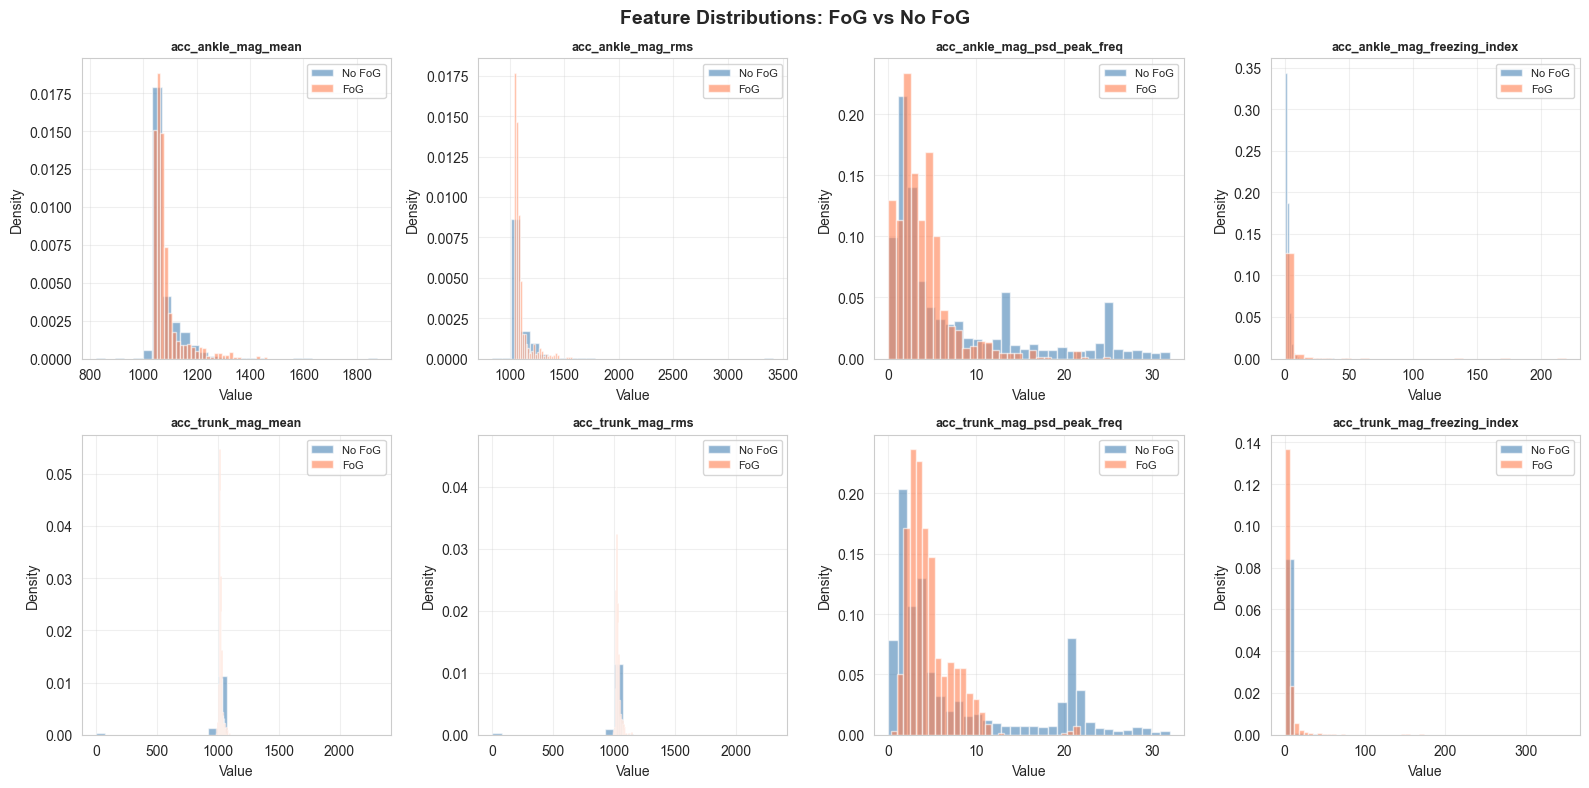

In [34]:
# Separate by class
features_no_fog = X_train_features[y_train == 0].replace([np.inf, -np.inf], np.nan)
features_fog    = X_train_features[y_train == 1].replace([np.inf, -np.inf], np.nan)

print(f"📊 Class Distribution:")
print(f"   No FoG: {len(features_no_fog):,} windows ({len(features_no_fog)/len(X_train_features)*100:.1f}%)")
print(f"   FoG: {len(features_fog):,} windows ({len(features_fog)/len(X_train_features)*100:.1f}%)")

# Select representative features (per-group magnitudes)
feature_subset = [
    'acc_ankle_mag_mean', 'acc_ankle_mag_rms',
    'acc_ankle_mag_psd_peak_freq', 'acc_ankle_mag_freezing_index',
    'acc_trunk_mag_mean', 'acc_trunk_mag_rms',
    'acc_trunk_mag_psd_peak_freq', 'acc_trunk_mag_freezing_index',
]

# Filter to existing features
feature_subset = [f for f in feature_subset if f in X_train_features.columns]

# Visualize distributions
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for i, feat in enumerate(feature_subset[:8]):
    axes[i].hist(features_no_fog[feat].dropna(), bins=30, alpha=0.6,
                 label='No FoG', color='steelblue', density=True)
    axes[i].hist(features_fog[feat].dropna(), bins=30, alpha=0.6,
                 label='FoG', color='coral', density=True)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

# Hide unused subplots
for i in range(len(feature_subset), 8):
    axes[i].axis('off')

plt.suptitle('Feature Distributions: FoG vs No FoG', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance by Variance

Identify features with highest variance (potentially most discriminative).

📊 Top 15 Features by Variance:
 1. ch4_wavelet_energy_0                13453817505539290.00
 2. acc_thigh_mag_wavelet_energy_0      7310052187965782.00
 3. ch3_wavelet_energy_0                7270527633517280.00
 4. acc_trunk_mag_wavelet_energy_0      4512361412824062.00
 5. ch1_wavelet_energy_0                3582052630725051.00
 6. acc_ankle_mag_wavelet_energy_0      3135132910095869.50
 7. ch7_wavelet_energy_0                2877658784419558.50
 8. ch8_wavelet_energy_0                2790540253890151.50
 9. ch0_wavelet_energy_0                1486602823655172.50
10. ch5_wavelet_energy_0                1179234094720981.75
11. ch2_wavelet_energy_0                437049160233005.38
12. ch6_wavelet_energy_0                383673068620883.19
13. ch3_wavelet_energy_1                106465179359736.50
14. ch3_wavelet_energy_2                41409631472803.91
15. ch1_wavelet_energy_1                19938444717875.73


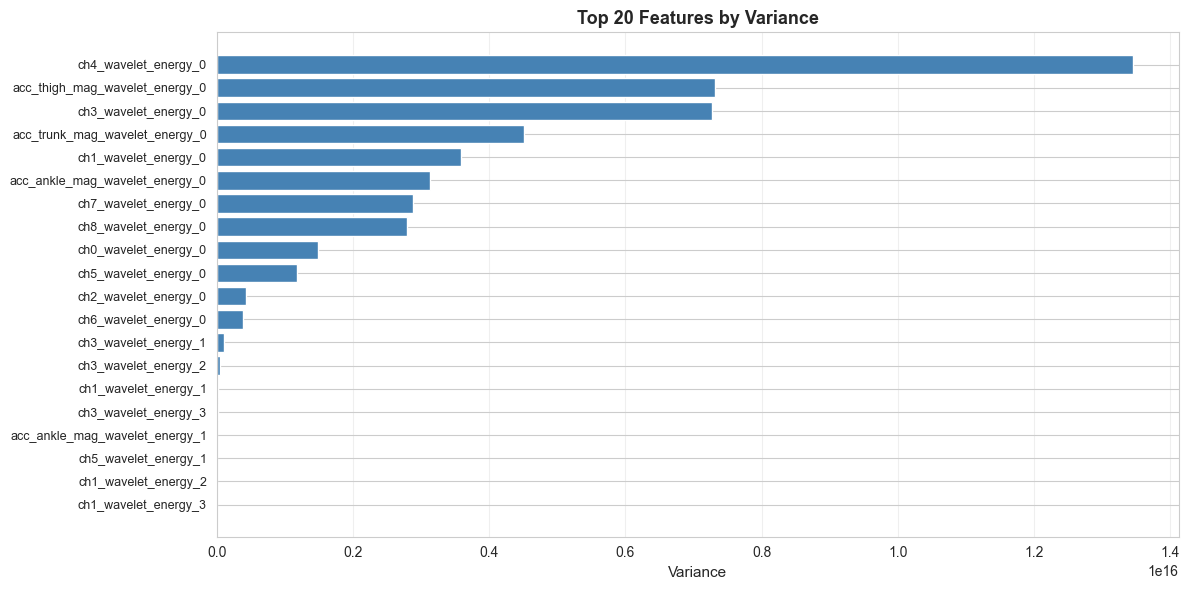

In [35]:
# Calculate variance for each feature (replace inf with NaN before var to avoid inf results)
feature_variance = (X_train_features
                    .replace([np.inf, -np.inf], np.nan)
                    .var()
                    .sort_values(ascending=False))

print("📊 Top 15 Features by Variance:")
print("=" * 60)
for i, (feat, var) in enumerate(feature_variance.head(15).items(), 1):
    print(f"{i:2d}. {feat:35s} {var:12.2f}")

# Visualize top features by variance
fig, ax = plt.subplots(figsize=(12, 6))
top_features = feature_variance.dropna().head(20)
ax.barh(range(len(top_features)), top_features.values, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features.index, fontsize=9)
ax.set_xlabel('Variance', fontsize=11)
ax.set_title('Top 20 Features by Variance', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 8. Feature Correlation Analysis

Identify highly correlated features (potential redundancy).

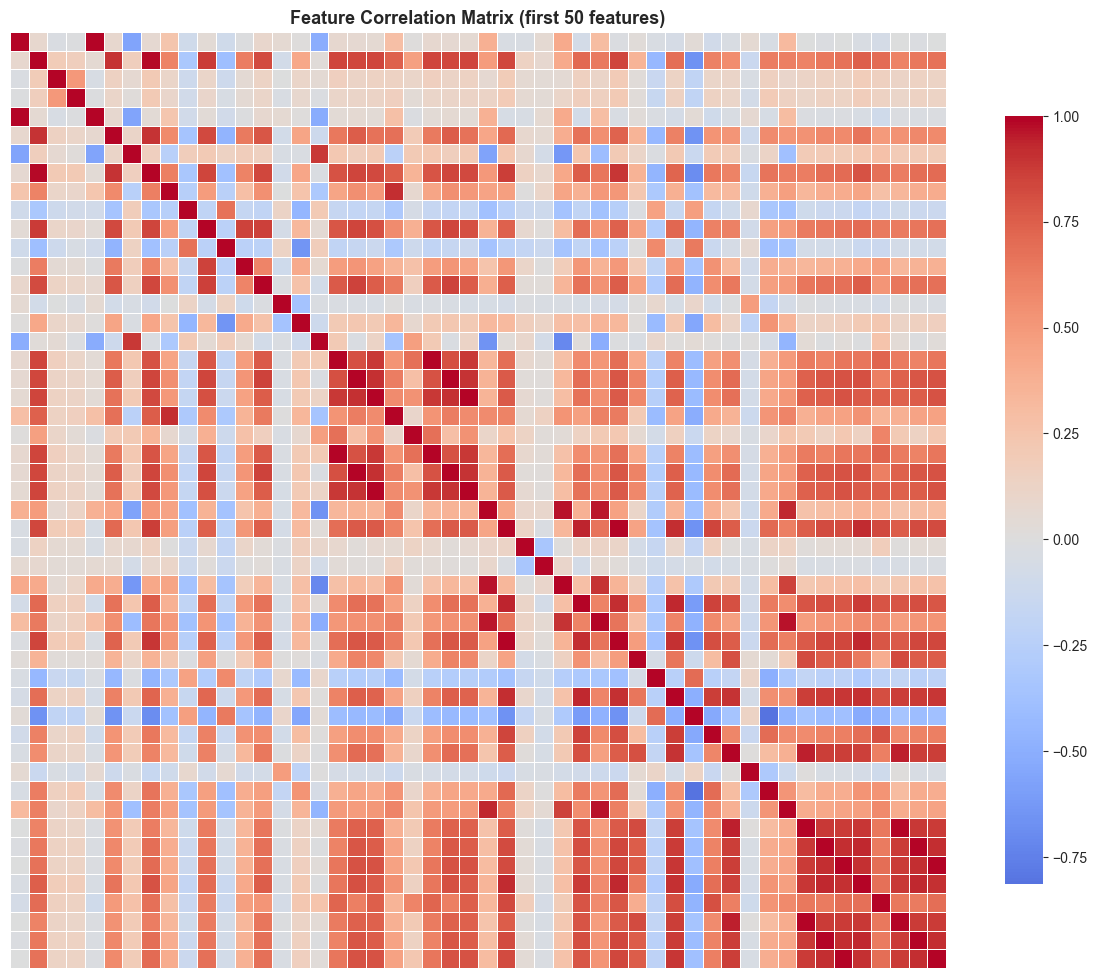


⚠️  Highly correlated pairs (|r| > 0.9): 36

Top 10 correlations:
  ch1_wavelet_energy_3           <-> ch1_wavelet_var_3             :  1.000
  ch0_wavelet_energy_3           <-> ch0_wavelet_var_3             :  1.000
  ch1_wavelet_energy_2           <-> ch1_wavelet_var_2             :  1.000
  ch0_wavelet_energy_2           <-> ch0_wavelet_var_2             :  1.000
  ch1_wavelet_energy_1           <-> ch1_wavelet_var_1             :  1.000
  ch0_wavelet_energy_1           <-> ch0_wavelet_var_1             :  1.000
  ch0_mean                       <-> ch0_median                    :  0.998
  ch1_std                        <-> ch1_peak_to_peak              :  0.992
  ch0_std                        <-> ch0_peak_to_peak              :  0.984
  ch1_rms                        <-> ch1_wavelet_energy_0          :  0.967


In [36]:
# Compute correlation matrix (replace inf with NaN before corr to avoid propagation)
n_features_viz = min(50, X_train_features.shape[1])
features_sample = (X_train_features
                   .replace([np.inf, -np.inf], np.nan)
                   .iloc[:, :n_features_viz])
corr_matrix = features_sample.corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            xticklabels=False, yticklabels=False)
ax.set_title(f'Feature Correlation Matrix (first {n_features_viz} features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Find highly correlated pairs
high_corr_threshold = 0.9
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if np.isfinite(val) and abs(val) > high_corr_threshold:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                val
            ))

print(f"\n⚠️  Highly correlated pairs (|r| > {high_corr_threshold}): {len(high_corr_pairs)}")
if len(high_corr_pairs) > 0:
    print("\nTop 10 correlations:")
    for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f"  {feat1:30s} <-> {feat2:30s}: {corr:6.3f}")

## 9. Class Separability Analysis

Measure how well features separate FoG from No FoG using effect size (Cohen's d).

📊 Top 15 Features by Effect Size (Cohen's d):
   Higher effect size = better class separability
   d > 0.8: Large effect
   d > 0.5: Medium effect
   d > 0.2: Small effect
 1. ch6_wavelet_energy_1                d=1.089  (Large)
 2. ch6_wavelet_var_2                   d=1.088  (Large)
 3. ch6_wavelet_var_1                   d=1.088  (Large)
 4. ch6_wavelet_energy_2                d=1.086  (Large)
 5. ch6_power_freeze_band               d=1.019  (Large)
 6. ch5_wavelet_entropy                 d=0.936  (Large)
 7. ch6_peak_to_peak                    d=0.919  (Large)
 8. acc_trunk_mag_wavelet_var_2         d=0.873  (Large)
 9. acc_trunk_mag_wavelet_energy_2      d=0.870  (Large)
10. ch6_std                             d=0.852  (Large)
11. acc_trunk_mag_wavelet_entropy       d=0.825  (Large)
12. ch6_wavelet_entropy                 d=0.822  (Large)
13. ch3_wavelet_entropy                 d=0.815  (Large)
14. ch7_wavelet_var_2                   d=0.806  (Large)
15. ch7_wavelet_energy_2      

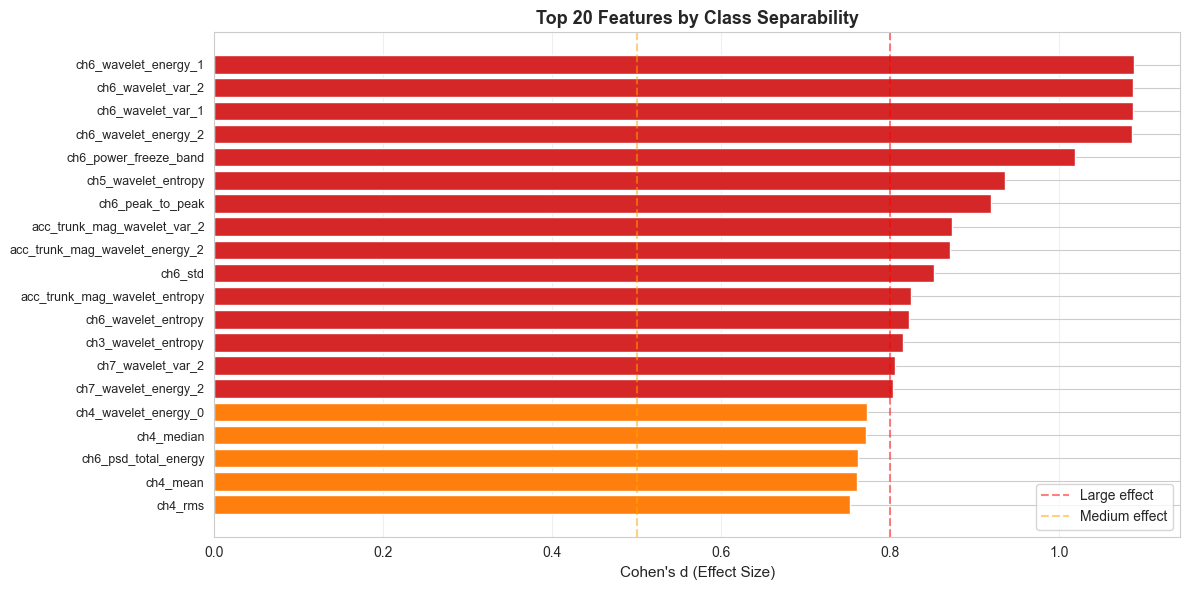

In [37]:
# Calculate Cohen's d for each feature
def cohens_d(group1, group2):
    """Calculate Cohen's d effect size."""
    mean1, mean2 = group1.mean(), group2.mean()
    std1, std2 = group1.std(), group2.std()
    n1, n2 = len(group1), len(group2)
    pooled_std = np.sqrt(((n1-1)*std1**2 + (n2-1)*std2**2) / (n1+n2-2))
    return abs((mean1 - mean2) / pooled_std) if pooled_std > 0 else 0

effect_sizes = {}
for col in X_train_features.columns:
    d = cohens_d(features_no_fog[col].dropna(), features_fog[col].dropna())
    effect_sizes[col] = d

effect_sizes = pd.Series(effect_sizes).sort_values(ascending=False)

print("📊 Top 15 Features by Effect Size (Cohen's d):")
print("=" * 70)
print("   Higher effect size = better class separability")
print("   d > 0.8: Large effect")
print("   d > 0.5: Medium effect")
print("   d > 0.2: Small effect")
print("=" * 70)
for i, (feat, d) in enumerate(effect_sizes.head(15).items(), 1):
    magnitude = "Large" if d > 0.8 else "Medium" if d > 0.5 else "Small" if d > 0.2 else "Negligible"
    print(f"{i:2d}. {feat:35s} d={d:5.3f}  ({magnitude})")

# Visualize top features by effect size
fig, ax = plt.subplots(figsize=(12, 6))
top_effects = effect_sizes.head(20)
colors = ['#d62728' if d > 0.8 else '#ff7f0e' if d > 0.5 else '#2ca02c' for d in top_effects.values]
ax.barh(range(len(top_effects)), top_effects.values, color=colors)
ax.set_yticks(range(len(top_effects)))
ax.set_yticklabels(top_effects.index, fontsize=9)
ax.set_xlabel("Cohen's d (Effect Size)", fontsize=11)
ax.set_title('Top 20 Features by Class Separability', fontsize=13, fontweight='bold')
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.5, label='Large effect')
ax.axvline(x=0.5, color='orange', linestyle='--', alpha=0.5, label='Medium effect')
ax.legend()
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Summary

In [38]:
# Summary statistics
total_train = sum([len(fold['y_train']) for fold in loso_splits])
total_test = sum([len(fold['y_test']) for fold in loso_splits])

print("=" * 70)
print("FEATURE EXTRACTION SUMMARY")
print("=" * 70)

print(f"\n📊 Feature Configuration:")
print(f"   Time-domain: ✅ Enabled")
print(f"   Frequency-domain: ✅ Enabled")
print(f"   Wavelet: ✅ Enabled")
print(f"   Nonlinear: ❌ Disabled")

print(f"\n📈 Processing Statistics:")
print(f"   LOSO folds: {len(loso_splits)}")
print(f"   Total train windows: {total_train:,}")
print(f"   Total test windows: {total_test:,}")
print(f"   Features per window: {X_train_features.shape[1]}")

print(f"\n🧹 Signal Cleaning:")
print(f"   Method: MAD-based outlier detection")
print(f"   Interpolation: Polynomial (order 3)")
print(f"   Threshold: 3.0 × MAD")

print(f"\n💾 Output:")
print(f"   Directory: {feature_output_dir}")
print(f"   Files per fold: X_train_features.csv, y_train.csv, X_test_features.csv, y_test.csv")

print(f"\n🎯 Key Insights:")
print(f"   Top feature (variance): {feature_variance.index[0]}")
print(f"   Top feature (effect size): {effect_sizes.index[0]} (d={effect_sizes.iloc[0]:.3f})")
print(f"   Highly correlated pairs: {len(high_corr_pairs)}")

print("\n" + "=" * 70)
print("✅ Dataset ready for training!")
print("📌 Next step: Run notebook 04_loso_pipeline_and_training.ipynb")
print("=" * 70)

FEATURE EXTRACTION SUMMARY

📊 Feature Configuration:
   Time-domain: ✅ Enabled
   Frequency-domain: ✅ Enabled
   Wavelet: ✅ Enabled
   Nonlinear: ❌ Disabled

📈 Processing Statistics:
   LOSO folds: 10
   Total train windows: 80,055
   Total test windows: 4,451
   Features per window: 301

🧹 Signal Cleaning:
   Method: MAD-based outlier detection
   Interpolation: Polynomial (order 3)
   Threshold: 3.0 × MAD

💾 Output:
   Directory: ..\..\outputs\daphnet_features
   Files per fold: X_train_features.csv, y_train.csv, X_test_features.csv, y_test.csv

🎯 Key Insights:
   Top feature (variance): ch4_wavelet_energy_0
   Top feature (effect size): ch6_wavelet_energy_1 (d=1.089)
   Highly correlated pairs: 36

✅ Dataset ready for training!
📌 Next step: Run notebook 04_loso_pipeline_and_training.ipynb
